<p align="center">
<img alt="Institution Logo" src="nhsm.png" width="120"/>
</p>

# Image Analysis Workshop - Lab 1

**Institution:** National Higher School of Mathematics  
**Course:** Image Analysis WORKSHOP  
**Instructor:** Pr. Amel Bouchemha  
**Date:** 06 / 03 / 2026  

---

**Full Name:** Zeroual Oussama  
**Student ID:** 202239345404  
**Group / Section:** MS S8 

---

## Introduction

This notebook demonstrates fundamental image processing techniques applied to both satellite and medical images. The main objectives are to load, analyze, and manipulate image data using Python libraries like `rasterio`, `OpenCV`, and `matplotlib`.

The following key image processing functions are implemented and tested:
* **Image Loading and Basic Analysis:** Inspecting image dimensions, bands, and data types.
* **Histogram Analysis:** Visualizing pixel intensity distribution.
* **Normalization and Quantization:** Reducing the number of gray levels.
* **Gamma Correction:** Adjusting image brightness.
* **Histogram Equalization:** Enhancing image contrast.
* **Contrast Stretching:** Improving image contrast for visualization.
* **SAR Decibel Conversion:** Converting radar image values to decibels (dB).

---

## 1. Setup and Image Loading

This section imports all necessary Python libraries. The primary libraries are:
* `rasterio`: For reading geospatial raster data (`.tif` files).
* `opencv-python` (`cv2`): For general image processing tasks.
* `numpy`: For numerical operations on image arrays.
* `matplotlib`: For displaying images and plotting graphs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import rasterio
import os

### ReadingTest Images

In this code cell we  read the actual image files.

Landsat image loaded successfully. Shape: (1, 73, 106), Bands: 1
Bandes: 1
Largeur: 106, Hauteur: 73
Projection: EPSG:32631


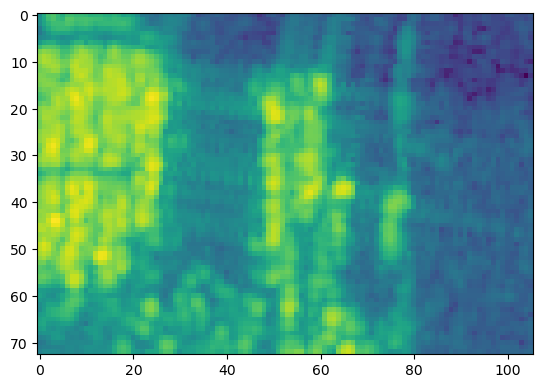

In [7]:
with rasterio.open('Algeria_Ship_Detection_SAR.tif') as src:
    landsat_img = src.read()  # Reading all bands
    print(f"Landsat image loaded successfully. Shape: {landsat_img.shape}, Bands: {src.count}")
mri_img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Display metadata
print(f"Bandes: {landsat_img.shape[0]}")
print(f"Largeur: {landsat_img.shape[2]}, Hauteur: {landsat_img.shape[1]}")
print(f"Projection: {src.crs}")

# 3. Read Data (Example: band 1)
bande1 = landsat_img[0]

# 4. View image
plt.imshow(bande1)
plt.show()

## 2. Function Implementations
### 2.1. Basic Image Display and Histogram

* **What it does**: This function `display_with_histogram` shows an image alongside its pixel intensity histogram. The histogram helps understand the distribution of bright and dark pixels.
* **Algorithm/Method**: It uses `matplotlib` to create a figure with two subplots. The first subplot displays the image using `imshow()`. The second subplot plots a histogram of the image's pixel values using `plt.hist()`.

In [47]:
def display_with_histogram(image, title="Image", bins=50, cmap='gray', figsize=(12, 4)):
    plt.figure(figsize=figsize)

    # Subplot 1: The image
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.colorbar()

    # Subplot 2: The histogram
    plt.subplot(1, 2, 2)
    plt.hist(image.flatten(), bins=bins, alpha=0.7, color='steelblue', edgecolor='black')
    plt.title(f'Histogram of {title}')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### 2.2. Gamma Correction

* **What it does**: This function `gamma_correction` applies a power-law transformation to an image. The formula is `output = input^(1/gamma)`. Values are first normalized to the range [0, 1].
* **Algorithm/Method**:
    1. Normalize the image to the range [0, 1].
    2. Apply the power-law transformation `output = input^(1/gamma)`.
    3. Scale the result back to the original data range (e.g., 0-255 for 8-bit images).

In [48]:
def gamma_correction(image, gamma=1.0):
    
    # Normalize the image to the range [0, 1]
    if image.max() > 1.0:
        normalized = image.astype(float) / image.max()
    else:
        normalized = image.copy()
    corrected = np.power(normalized, 1/gamma)
    if image.max() > 1.0:
        result = (corrected * image.max()).astype(image.dtype)
    else:
        result = corrected
        
    return result

### 2.3. Histogram Equalization

* **What it does**: This function `histogram_equalization` redistributes pixel intensities to create a more uniform histogram, which often enhances the global contrast of the image.
* **Algorithm/Method**: It uses OpenCV's `cv2.equalizeHist()` function, which calculates the cumulative distribution function (CDF) of the pixel intensities and maps the original values to new ones based on this CDF.

In [49]:
def histogram_equalization(image):
    if image.dtype != np.uint8:
        image_norm = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        equalized = cv2.equalizeHist(image_norm)
        if image.max() > 255:
            result = (equalized.astype(float) / 255.0 * image.max()).astype(image.dtype)
        else:
            result = equalized
    else:
        result = cv2.equalizeHist(image)
        
    return result

### 2.4. Image Quantization

* **What it does**: This function `quantize_image` reduces the number of gray levels in an image. For example, from 256 levels (8-bit) to 64, 32, or 16 levels.
* **Algorithm/Method**:
    1. Calculate the step size: `256 // levels`.
    2. Quantize by integer division: `image // step_size * step_size`.

In [50]:
def quantize_image(image, levels=256):
    if image.dtype != np.uint8:
        temp = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        temp = image.copy()
    
    step = 256 // levels
    quantized = (temp // step) * step
    
    return quantized.astype(np.uint8)

### 2.5. Linear Contrast Stretching

* **What it does**: This function `linear_stretch` enhances contrast by "stretching" the range of pixel intensities. It maps a specified lower percentile of pixels to 0 and a specified upper percentile to 1, linearly scaling all values in between.
* **Algorithm/Method**:
    1. Calculate the pixel values at the given lower (`p_low`) and upper (`p_high`) percentiles using `np.percentile`.
    2. Apply the linear mapping: `stretched = (image - p_low) / (p_high - p_low)`.
    3. Clip values outside the new range to 0 and 1.

In [51]:
def linear_stretch(image, percent=2):
    p_low, p_high = np.percentile(image, [percent, 100 - percent])
    if p_high == p_low:
        return np.zeros_like(image, dtype=float)
    stretched = (image.astype(float) - p_low) / (p_high - p_low)
    stretched = np.clip(stretched, 0, 1)
    return stretched

### 2.6. SAR Decibel Conversion

* **What it does**: This function `to_decibels` converts pixel values from Synthetic Aperture Radar (SAR) images to decibels (dB), which is a standard unit for representing radar backscatter.
* **Algorithm/Method**: The conversion uses the formula `dB = 10 * log10(intensity)`. A small epsilon value is added to the intensity to avoid taking the logarithm of zero, which is undefined.
* **Purpose**: SAR data often has a very wide dynamic range. Converting to a logarithmic decibel scale compresses this range, making the data easier to visualize and interpret.

In [52]:
def to_decibels(image):
    eps = 1e-10  
    db_image = 10 * np.log10(image.astype(float) + eps)
    return db_image

---

## 3. Testing on Landsat (.tif) Image

This section tests all implemented functions on the first band of the Landsat image. The image's data type is `uint16`, which has a range of 0-65535. Functions that expect `uint8` (0-255) input, like OpenCV's histogram equalization, require the image to be normalized first.

Selected first band from 13-band image
Landsat band 1 shape: (64, 64), dtype: uint16
Pixel value range: 1101 to 1319

=== Original Landsat Band 1 ===


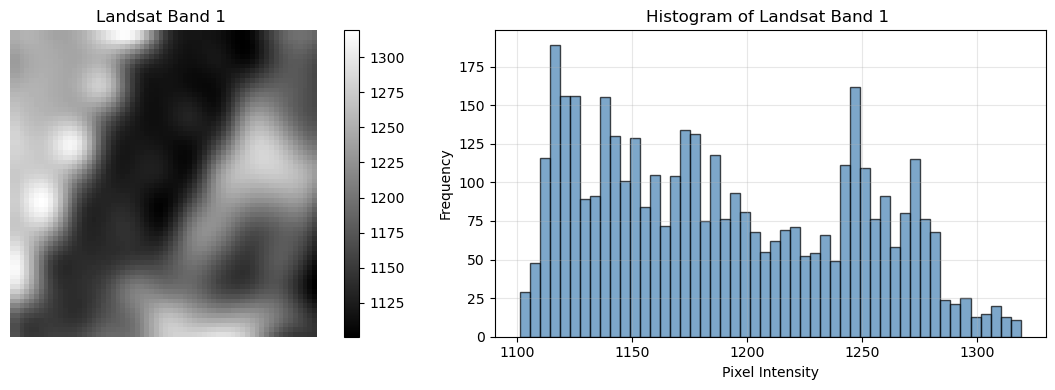

In [53]:

if len(landsat_img.shape) == 3:
    landsat_band1 = landsat_img[0]  
    print(f"Selected first band from {landsat_img.shape[0]}-band image")
else:
    landsat_band1 = landsat_img

print(f"Landsat band 1 shape: {landsat_band1.shape}, dtype: {landsat_band1.dtype}")
print(f"Pixel value range: {landsat_band1.min()} to {landsat_band1.max()}")
print("\n=== Original Landsat Band 1 ===")
display_with_histogram(landsat_band1, title="Landsat Band 1 ", bins=50, figsize=(12, 4))


=== Normalized Landsat Band 1 ===


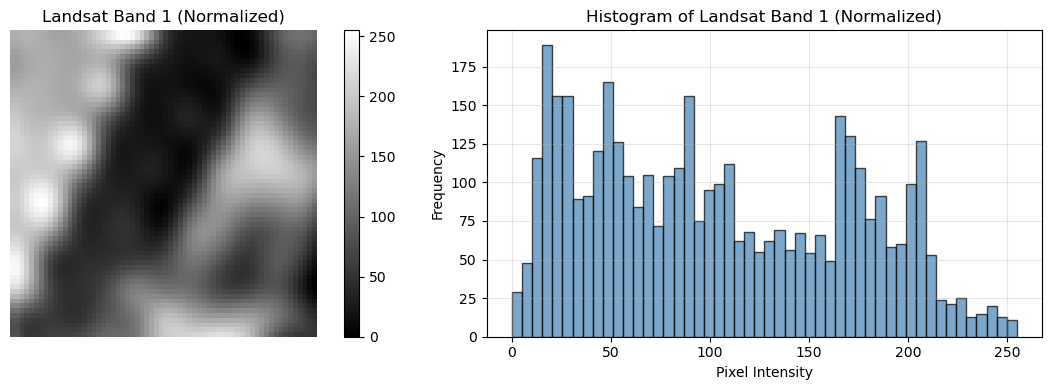

In [61]:
landsat_norm = cv2.normalize(landsat_band1, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
print("\n=== Normalized Landsat Band 1 ===")
display_with_histogram(landsat_norm, title="Landsat Band 1 (Normalized)", bins=50, figsize=(12, 4))

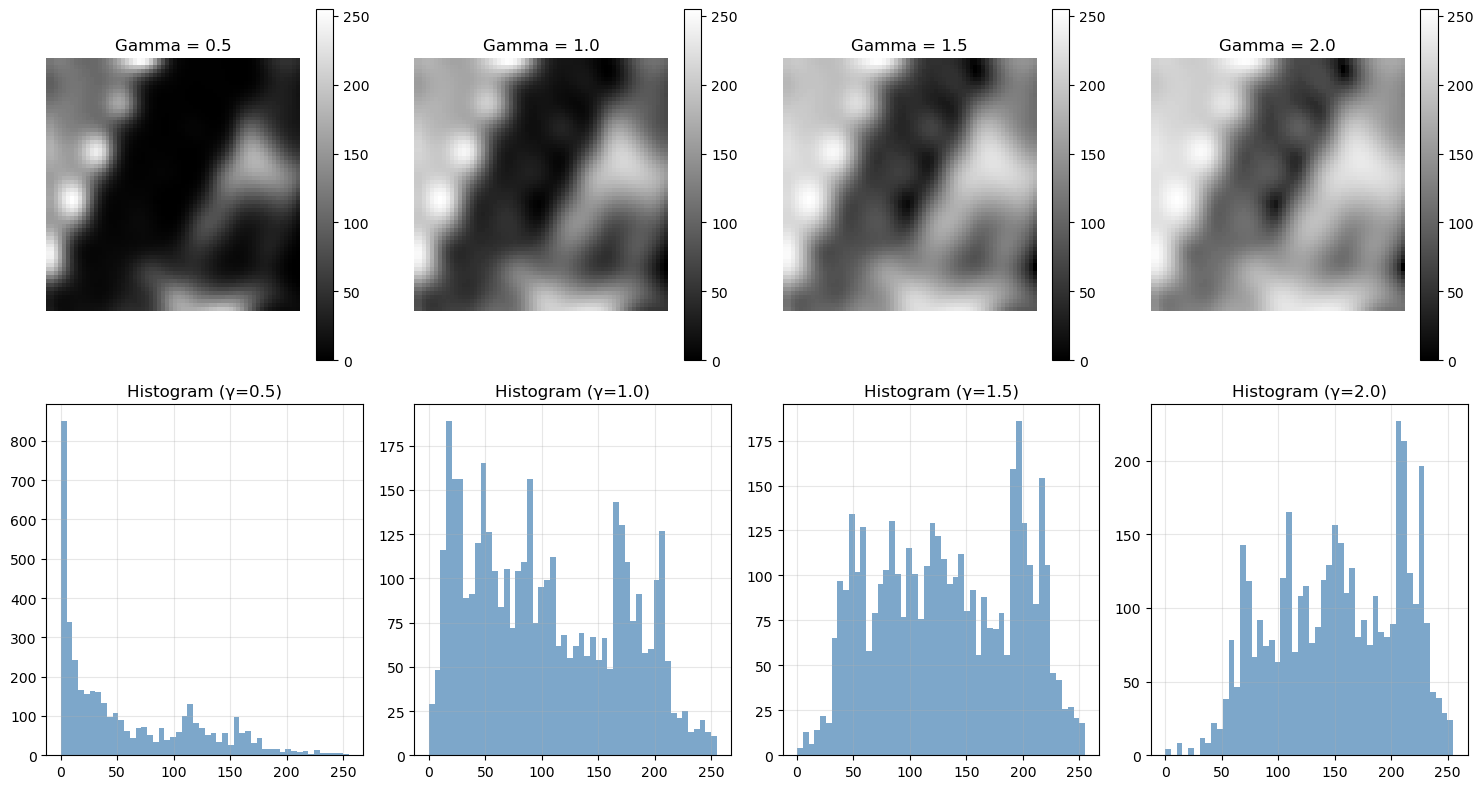

In [62]:

gamma_values = [0.5, 1.0, 1.5, 2.0]
plt.figure(figsize=(15, 8))

for i, gamma in enumerate(gamma_values):
    corrected = gamma_correction(landsat_norm, gamma)
    
    plt.subplot(2, 4, i+1)
    plt.imshow(corrected, cmap='gray')
    plt.title(f'Gamma = {gamma}')
    plt.axis('off')
    plt.colorbar()
    
    plt.subplot(2, 4, i+5)
    plt.hist(corrected.flatten(), bins=50, alpha=0.7, color='steelblue')
    plt.title(f'Histogram (γ={gamma})')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

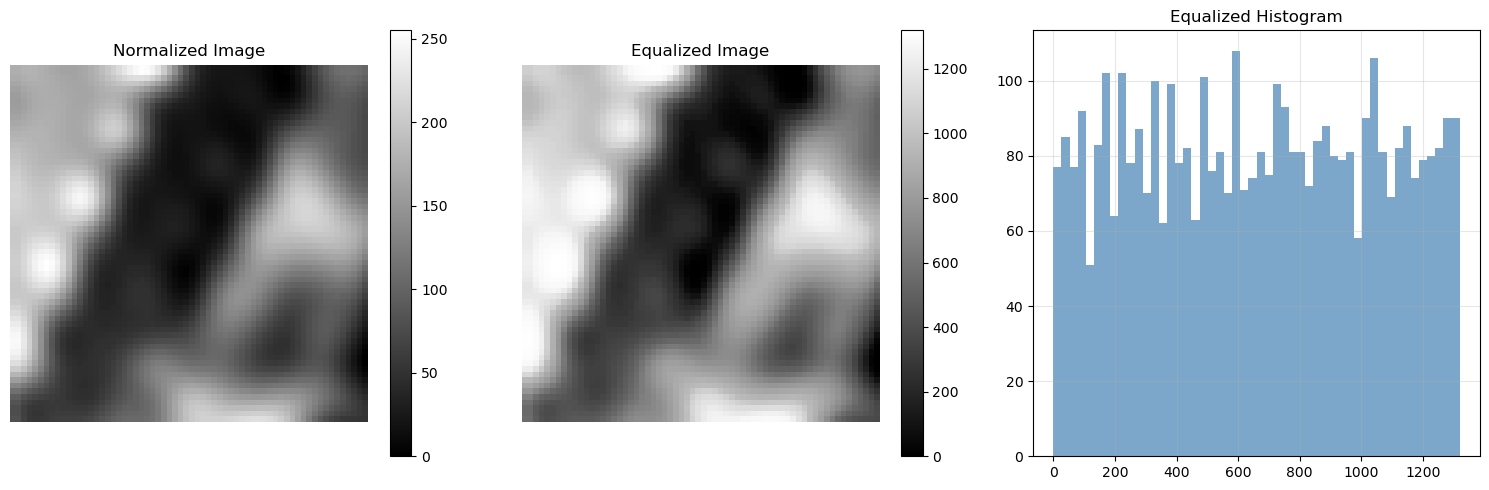

In [63]:
landsat_equalized = histogram_equalization(landsat_band1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(landsat_norm, cmap='gray')
plt.title('Normalized Image')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(landsat_equalized, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.hist(landsat_equalized.flatten(), bins=50, alpha=0.7, color='steelblue')
plt.title('Equalized Histogram')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

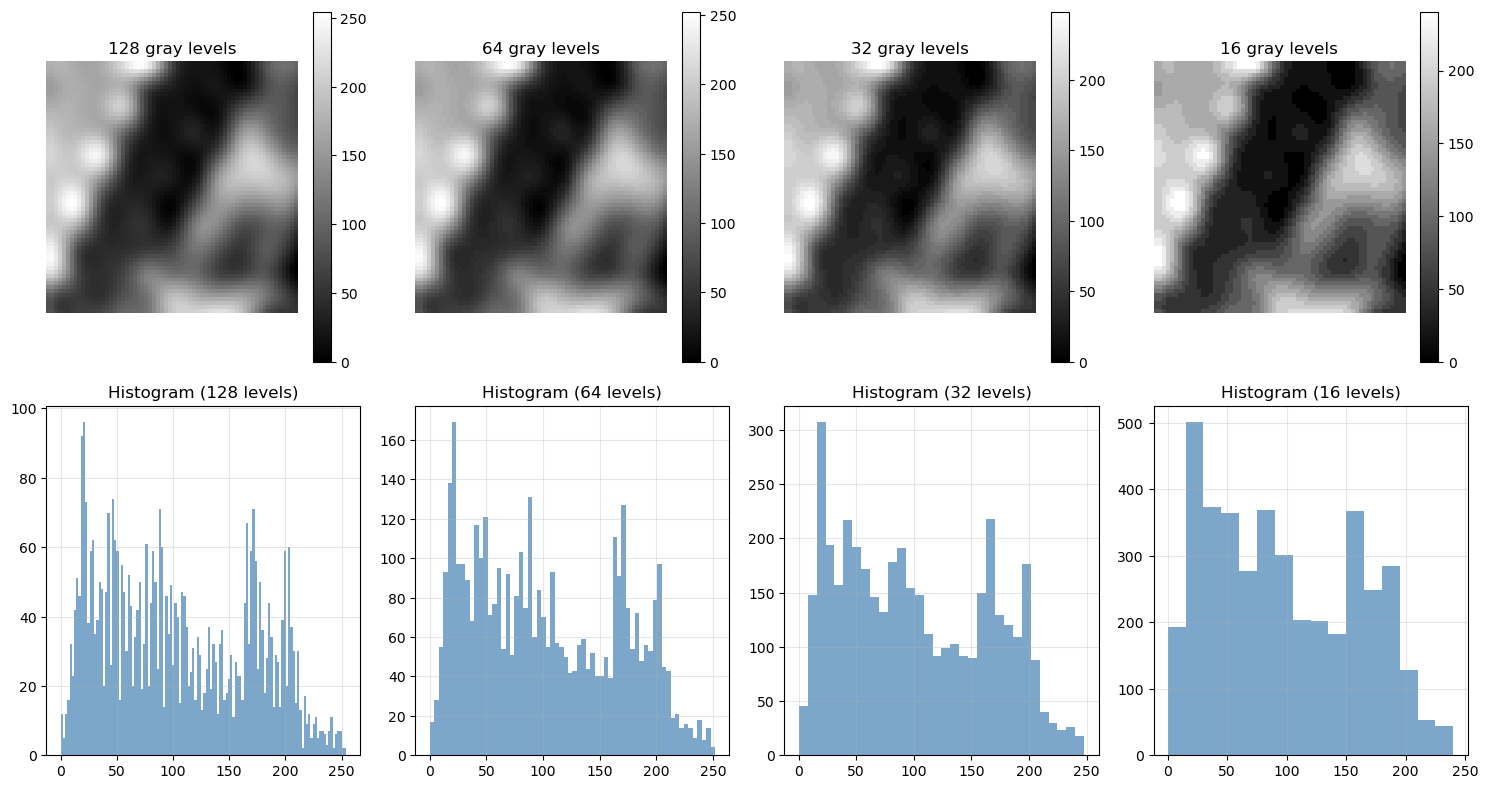

In [64]:

quantization_levels = [128, 64, 32, 16]

plt.figure(figsize=(15, 8))

for i, levels in enumerate(quantization_levels):
    quantized = quantize_image(landsat_norm, levels)
    
    plt.subplot(2, 4, i+1)
    plt.imshow(quantized, cmap='gray')
    plt.title(f'{levels} gray levels')
    plt.axis('off')
    plt.colorbar()
    
    plt.subplot(2, 4, i+5)
    plt.hist(quantized.flatten(), bins=levels, alpha=0.7, color='steelblue')
    plt.title(f'Histogram ({levels} levels)')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

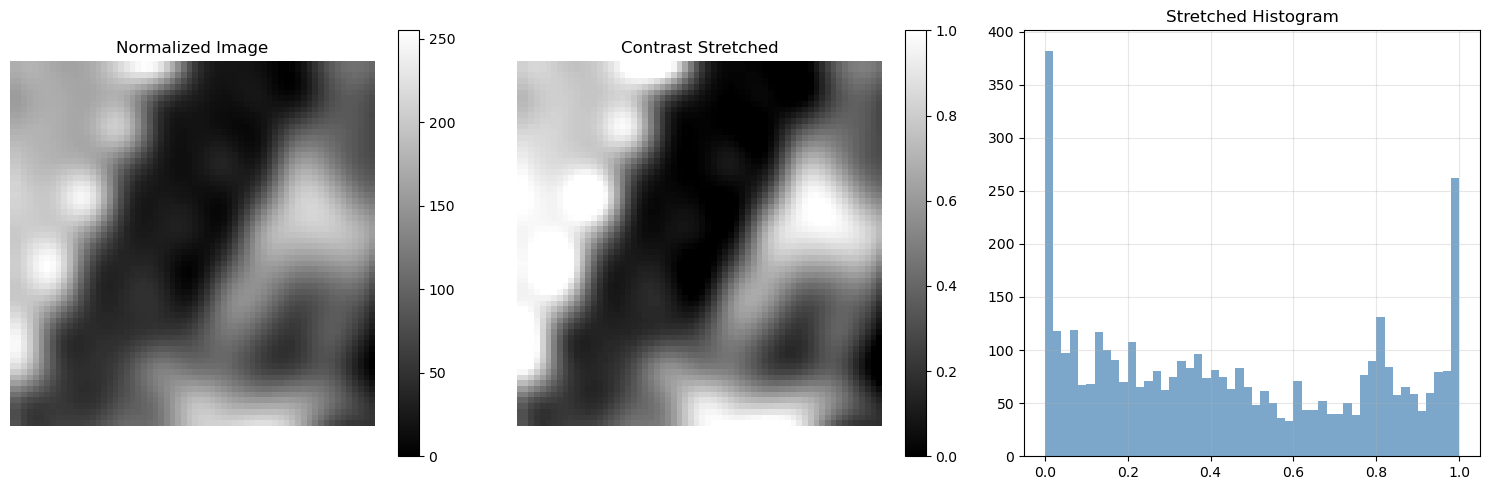

In [65]:

stretched = linear_stretch(landsat_band1, percent=5)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(landsat_norm, cmap='gray')
plt.title('Normalized Image')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(stretched, cmap='gray')
plt.title('Contrast Stretched')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.hist(stretched.flatten(), bins=50, alpha=0.7, color='steelblue')
plt.title('Stretched Histogram')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

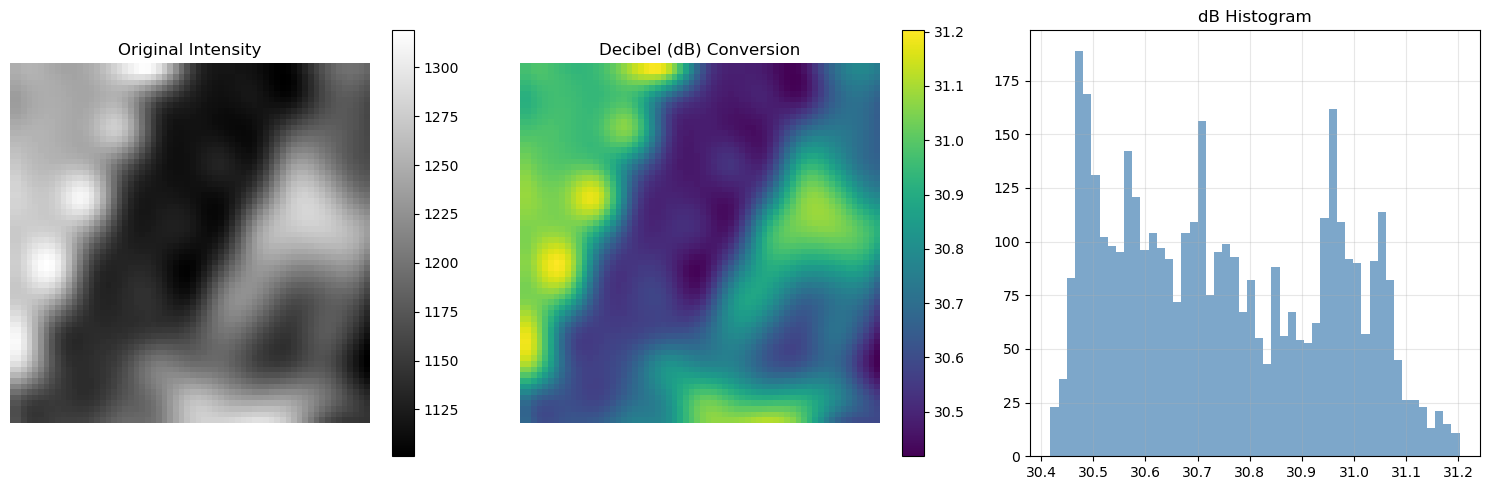

In [66]:

db_image = to_decibels(landsat_band1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(landsat_band1, cmap='gray')
plt.title('Original Intensity')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(db_image, cmap='viridis')
plt.title('Decibel (dB) Conversion')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.hist(db_image.flatten(), bins=50, alpha=0.7, color='steelblue')
plt.title('dB Histogram')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 4. Testing on MRI (.jpg) Image

This section tests all implemented functions on the MRI image. The MRI image is already in `uint8` format (0-255), which is directly compatible with most OpenCV functions.


MRI image shape: (590, 589), dtype: uint8
Pixel value range: 0 to 255


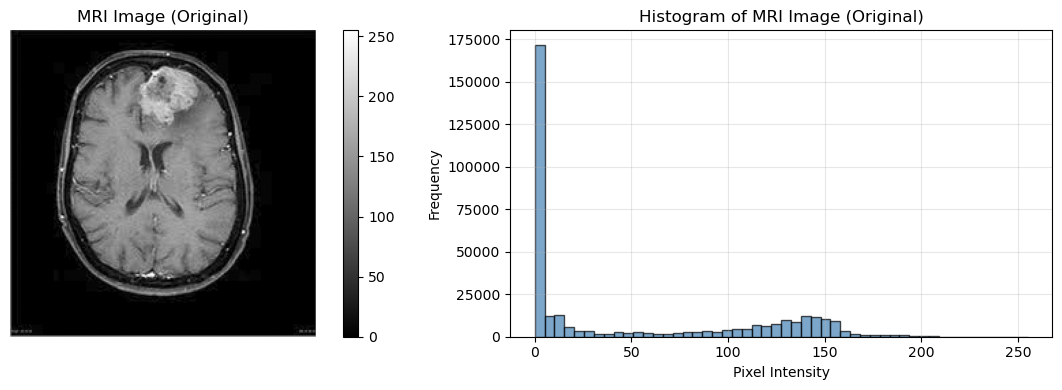

In [68]:
print(f"\nMRI image shape: {mri_img.shape}, dtype: {mri_img.dtype}")
print(f"Pixel value range: {mri_img.min()} to {mri_img.max()}")
display_with_histogram(mri_img, title="MRI Image (Original)", bins=50, figsize=(12, 4))

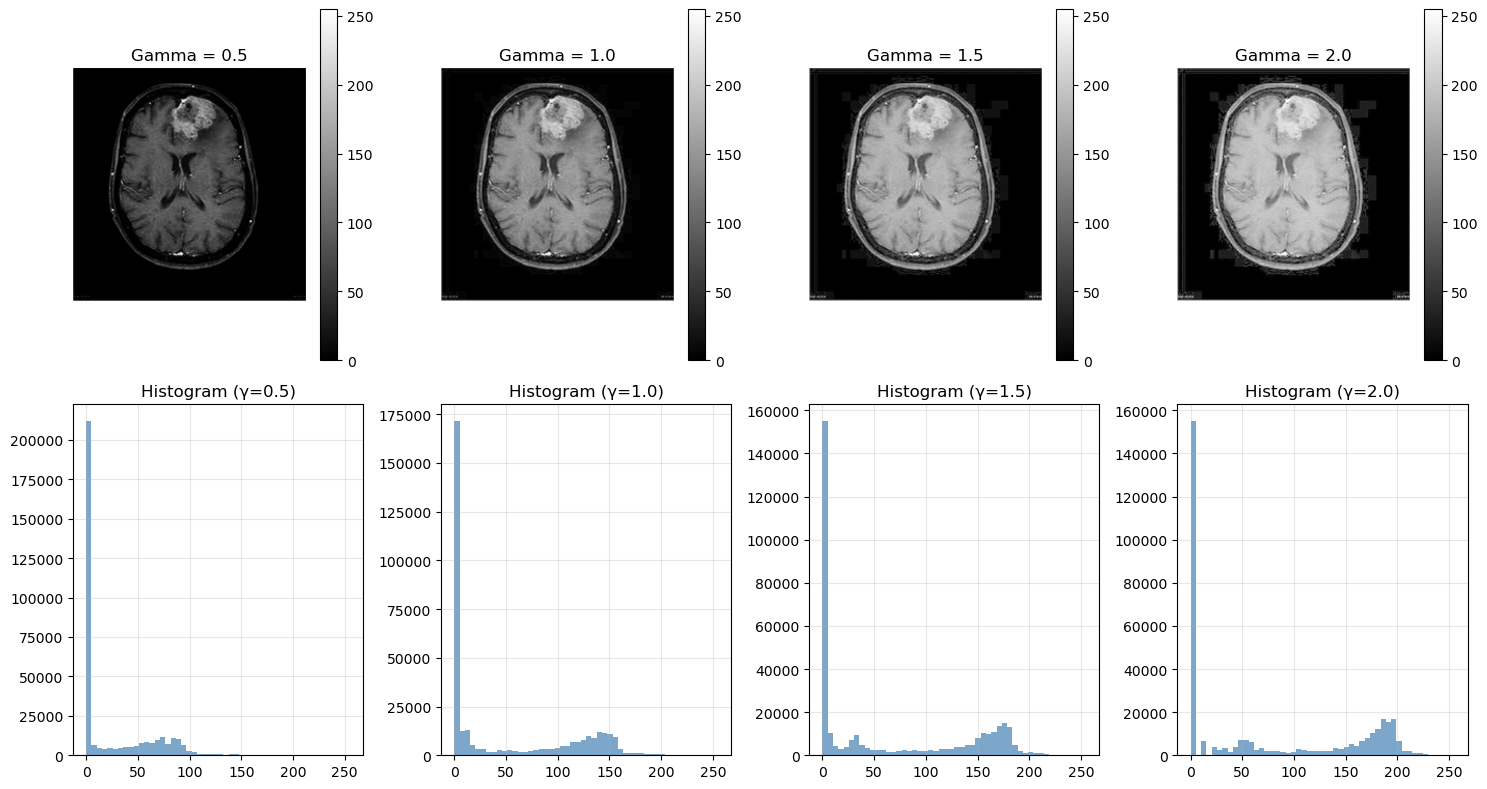

In [69]:

gamma_values = [0.5, 1.0, 1.5, 2.0]
plt.figure(figsize=(15, 8))

for i, gamma in enumerate(gamma_values):
    corrected = gamma_correction(mri_img, gamma)
    
    plt.subplot(2, 4, i+1)
    plt.imshow(corrected, cmap='gray')
    plt.title(f'Gamma = {gamma}')
    plt.axis('off')
    plt.colorbar()
    
    plt.subplot(2, 4, i+5)
    plt.hist(corrected.flatten(), bins=50, alpha=0.7, color='steelblue')
    plt.title(f'Histogram (γ={gamma})')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

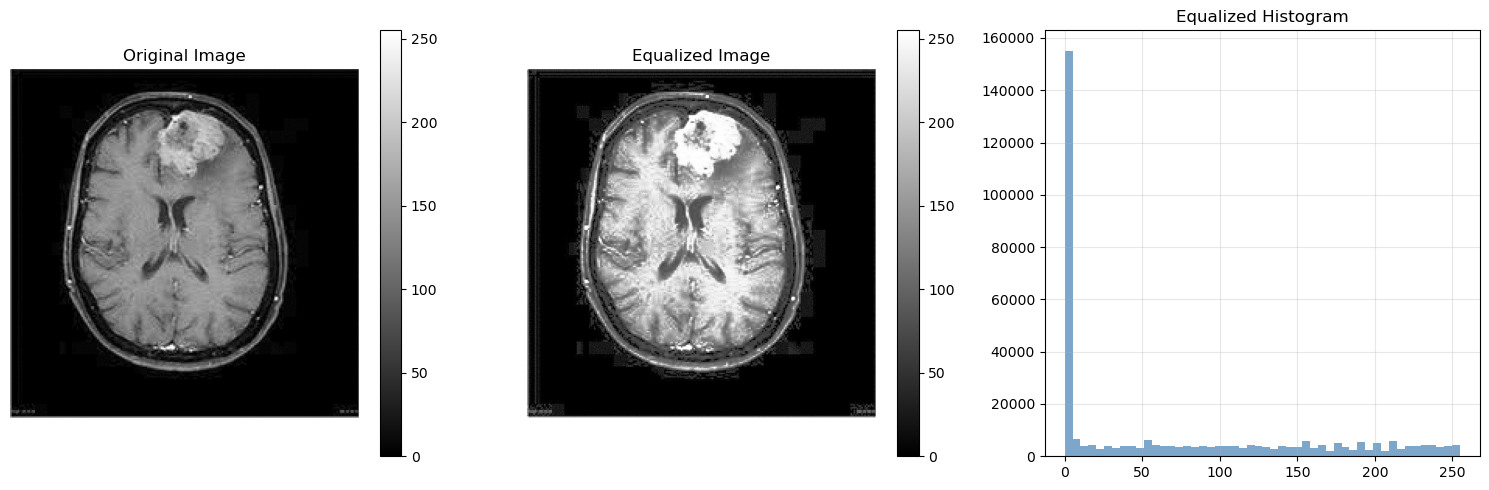

In [70]:

mri_equalized = histogram_equalization(mri_img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mri_img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(mri_equalized, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.hist(mri_equalized.flatten(), bins=50, alpha=0.7, color='steelblue')
plt.title('Equalized Histogram')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

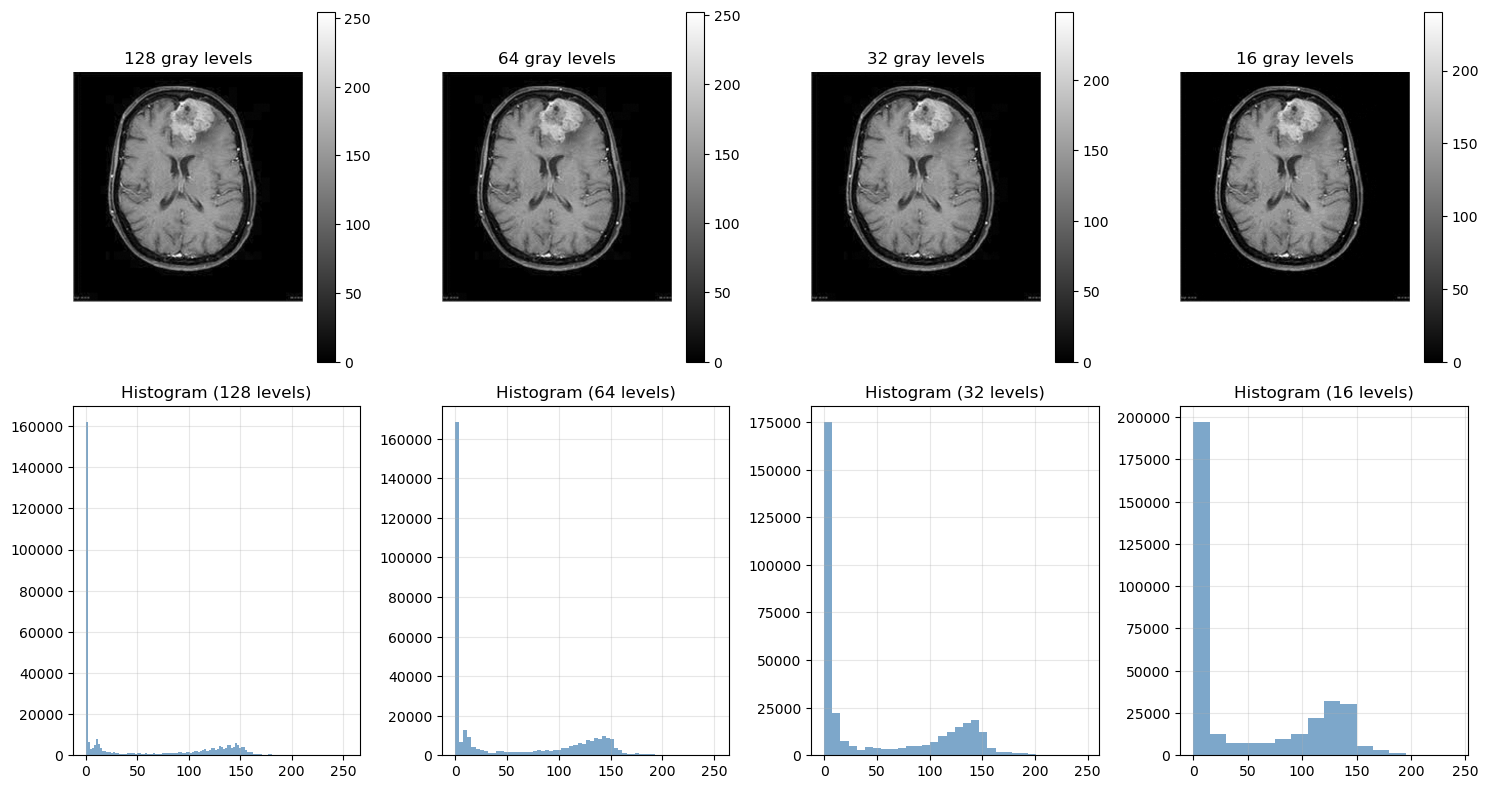

In [71]:

quantization_levels = [128, 64, 32, 16]

plt.figure(figsize=(15, 8))

for i, levels in enumerate(quantization_levels):
    quantized = quantize_image(mri_img, levels)
    
    plt.subplot(2, 4, i+1)
    plt.imshow(quantized, cmap='gray')
    plt.title(f'{levels} gray levels')
    plt.axis('off')
    plt.colorbar()
    
    plt.subplot(2, 4, i+5)
    plt.hist(quantized.flatten(), bins=levels, alpha=0.7, color='steelblue')
    plt.title(f'Histogram ({levels} levels)')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

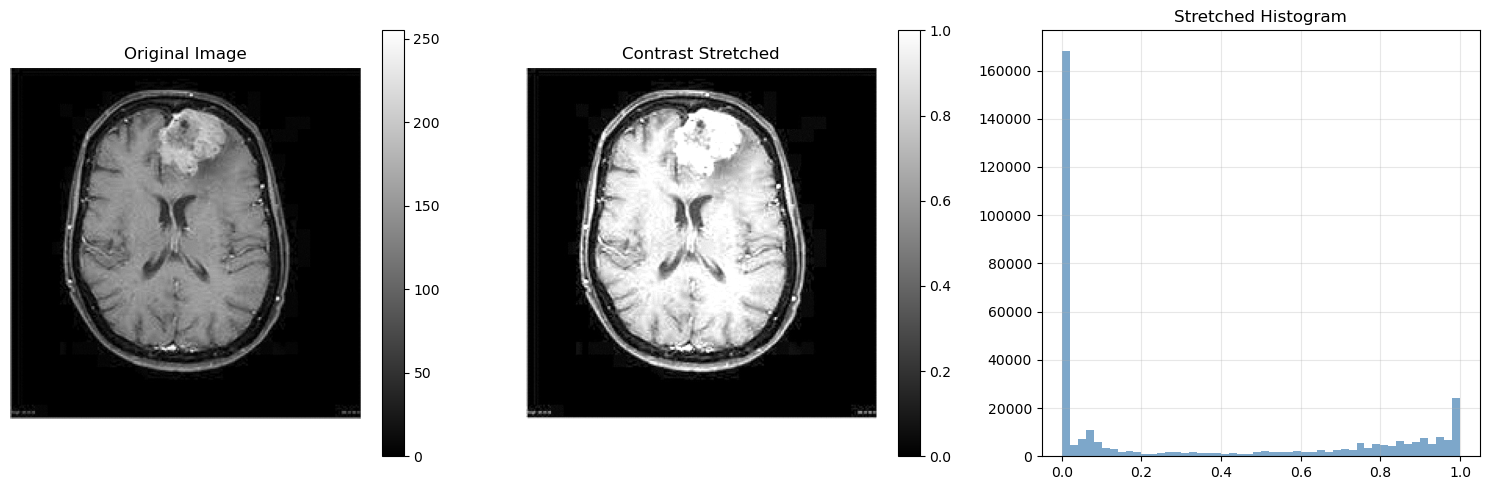

In [72]:

stretched = linear_stretch(mri_img, percent=5)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mri_img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(stretched, cmap='gray')
plt.title('Contrast Stretched')
plt.axis('off')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.hist(stretched.flatten(), bins=50, alpha=0.7, color='steelblue')
plt.title('Stretched Histogram')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Conclusion

In this lab, I have implemented and tested various image processing techniques such as :

1. **Image Loading and Analysis**: I loaded and analyzed both Landsat (multi-spectral) and MRI (grayscale) images.

2. **Gamma Correction**:  I showed how different gamma values affect image brightness and contrast. Gamma < 1 darkens images while gamma > 1 brightens them.

3. **Histogram Equalization**: This technique significantly improved image contrast by redistributing pixel intensities across the entire range.

4. **Image Quantization**: Reducing the number of gray levels demonstrated the trade-off between data compression and image quality.

5. **Contrast Stretching**: By stretching the intensity range, we enhanced the visual quality of images with narrow histograms.

6. **SAR Decibel Conversion**: Converting intensity values to decibels compressed the dynamic range, making it easier to visualize radar data.
